# Step 3: Feature Engineering
## Model Input-Output Contract
**Inputs (State Vector):**
$$S_t = [\text{macro}_t, \text{credit}_t, \text{market}_t]$$

**Outputs (Multi-Maturity Targets):**
$$Y_t = [y_1, y_2, y_5, y_{10}, y_{20}, y_{30}]$$


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

sys.path.append(str(Path.cwd().parent / 'Src'))
from feature_engineering import FeatureEngineer, MACRO_LEVELS, CREDIT_RISK, MARKET, TARGETS

plt.style.use('seaborn-v0_8-whitegrid')
DATA_PATH = Path.cwd().parent / 'Data'

---
## Section 1: Feature Construction

### 1.1 Feature Groups

In [2]:
# Load raw aligned panel
panel = pd.read_csv(DATA_PATH / 'Processed' / 'aligned_panel.csv', parse_dates=['date'])
print(f"Raw panel: {panel.shape}")

# Feature groups
feature_groups = {
    'Group 1 - Macro Levels': MACRO_LEVELS,
    'Group 2 - Macro Changes': [f'd_{c}' for c in MACRO_LEVELS],
    'Group 3 - Credit & Risk': CREDIT_RISK,
    'Group 4 - Market': MARKET
}

for group, cols in feature_groups.items():
    print(f"\n{group}:")
    print(f"  {cols}")

Raw panel: (118, 17)

Group 1 - Macro Levels:
  ['cpi', 'indpro', 'unrate', 'fedfunds', 'm2']

Group 2 - Macro Changes:
  ['d_cpi', 'd_indpro', 'd_unrate', 'd_fedfunds', 'd_m2']

Group 3 - Credit & Risk:
  ['baa', 'aaa', 'baa10y', 'vix']

Group 4 - Market:
  ['sp500']


### 1.2 Before/After Feature Engineering

In [3]:
# Apply feature engineering
fe = FeatureEngineer(train_ratio=0.8)
features, targets, feature_cols = fe.build_features(panel)

print("=" * 60)
print("BEFORE: Raw Panel (first 3 rows, selected columns)")
print("=" * 60)
print(panel[['date', 'cpi', 'fedfunds', 'vix', 'y10']].head(3))

print("\n" + "=" * 60)
print("AFTER: Normalized Features (first 3 rows)")
print("=" * 60)
print(features.head(3))

BEFORE: Raw Panel (first 3 rows, selected columns)
        date      cpi  fedfunds    vix   y10
0 2016-01-31  237.652      0.34  20.20  1.94
1 2016-02-29  237.336      0.38  20.55  1.74
2 2016-03-31  238.080      0.36  13.95  1.78

AFTER: Normalized Features (first 3 rows)
        date       cpi    indpro    unrate  fedfunds        m2       baa  \
0 2016-02-29 -1.274716 -0.324552  0.098239 -0.735583 -1.293309  1.026050   
1 2016-03-31 -1.239460 -0.563131  0.149857 -0.748706 -1.278316  0.772041   
2 2016-04-30 -1.196242 -0.455188  0.201474 -0.742145 -1.255045  0.360789   

        aaa    baa10y       vix     sp500     d_cpi  d_indpro  d_unrate  \
0  0.521120  3.233296  0.192219 -1.621159 -1.292212 -0.306648  0.094731   
1  0.336796  2.187776 -0.673973 -1.464539 -0.010518 -0.434154  0.094731   
2  0.073475  1.555600 -0.444301 -1.457710  0.192618  0.188160  0.094731   

   d_fedfunds      d_m2  
0   -0.068489 -0.095848  
1   -0.369408 -0.225254  
2   -0.218948 -0.054535  


In [4]:
# Summary statistics comparison
print("\nNormalized Feature Statistics:")
print(features[feature_cols].describe().round(3).T[['mean', 'std', 'min', 'max']])


Normalized Feature Statistics:
             mean    std    min    max
cpi         0.508  1.347 -1.275  2.881
indpro      0.040  0.901 -5.026  1.317
unrate     -0.065  0.901 -0.676  5.208
fedfunds    0.444  1.259 -0.952  2.512
m2          0.267  1.038 -1.293  1.577
baa         0.346  1.130 -1.611  2.586
aaa         0.437  1.248 -1.875  2.694
baa10y     -0.298  1.079 -1.946  4.157
vix        -0.074  0.923 -1.257  4.522
sp500       0.614  1.539 -1.621  4.418
d_cpi      -0.007  0.917 -3.382  3.652
d_indpro    0.005  0.904 -7.495  3.278
d_unrate    0.006  0.892 -1.892  8.991
d_fedfunds -0.117  0.950 -4.933  3.242
d_m2       -0.025  0.897 -2.408  5.614


---
## Section 2: Feature Distribution 

### 2.1 Histograms: Before vs After Normalization

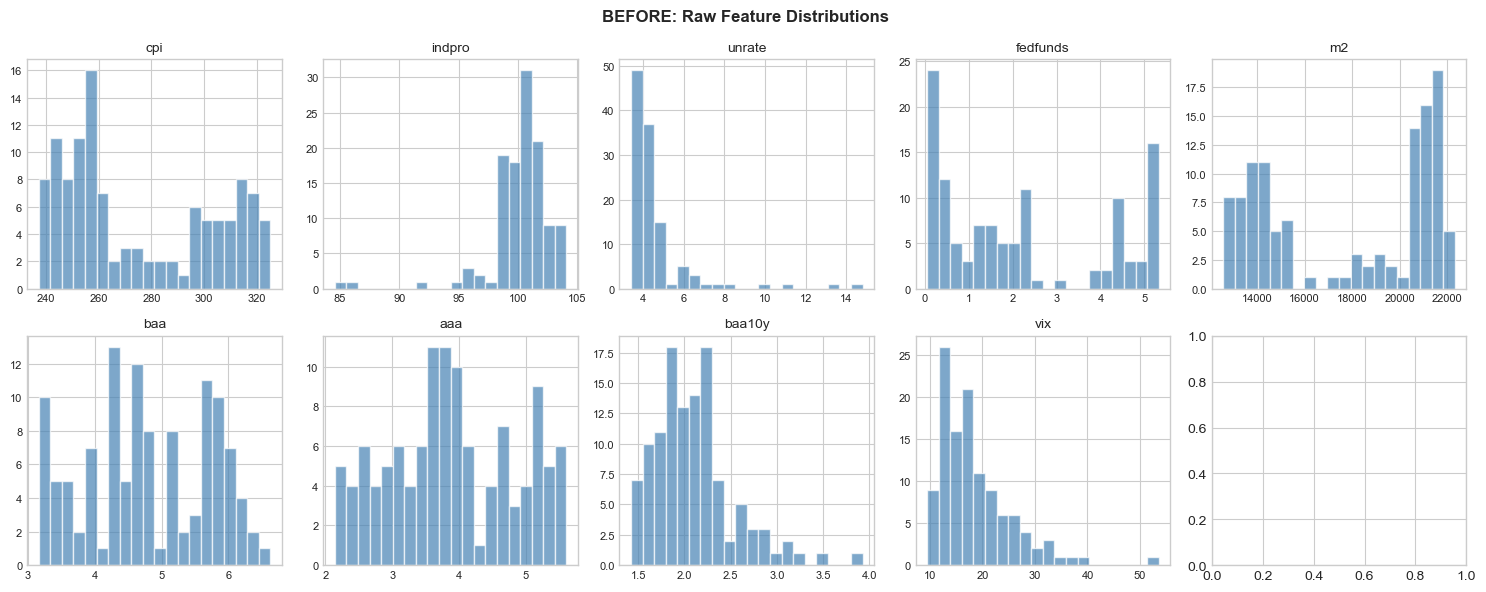

In [5]:
# Before normalization (raw levels)
raw_features = panel[MACRO_LEVELS + CREDIT_RISK + MARKET].iloc[1:]  # Drop first row like pipeline

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i, col in enumerate(MACRO_LEVELS + CREDIT_RISK[:4]):
    if i < len(axes):
        axes[i].hist(raw_features[col].dropna(), bins=20, alpha=0.7, color='steelblue', edgecolor='white')
        axes[i].set_title(col, fontsize=10)
        axes[i].tick_params(labelsize=8)

fig.suptitle('BEFORE: Raw Feature Distributions', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

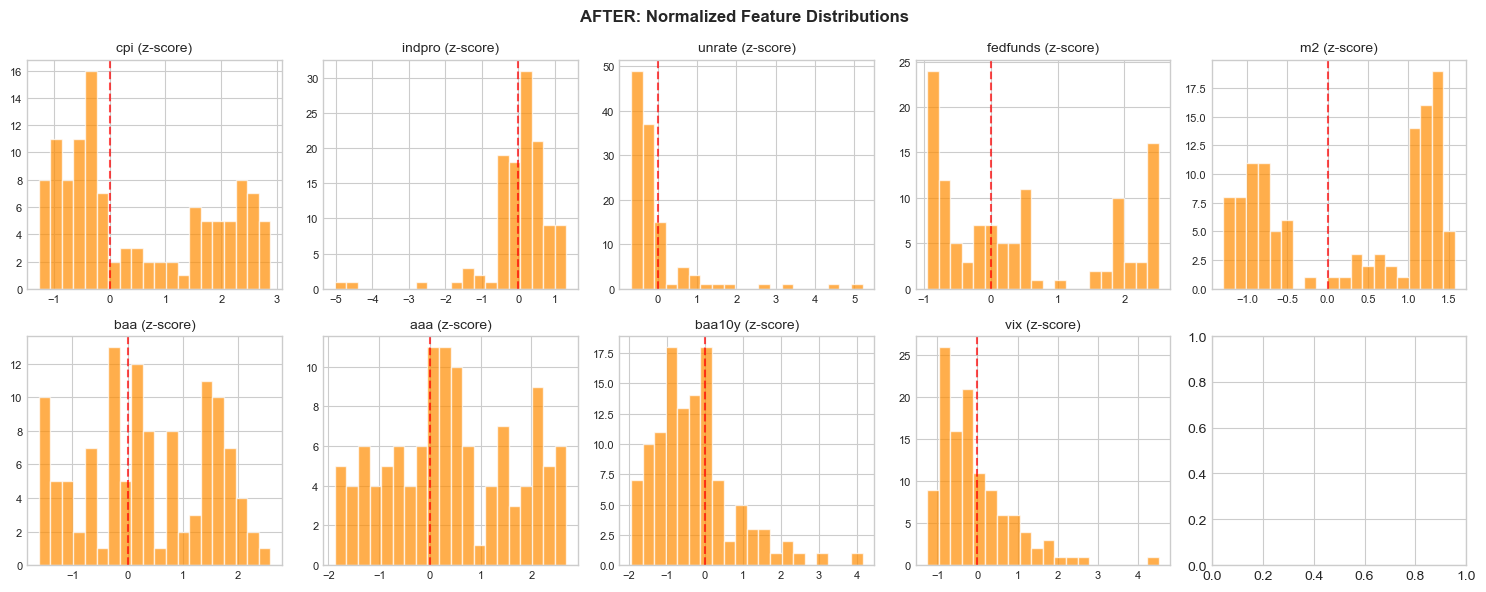

In [6]:
# After normalization
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

norm_cols = MACRO_LEVELS + CREDIT_RISK[:4]
for i, col in enumerate(norm_cols):
    if i < len(axes) and col in features.columns:
        axes[i].hist(features[col].dropna(), bins=20, alpha=0.7, color='darkorange', edgecolor='white')
        axes[i].axvline(0, color='red', linestyle='--', alpha=0.7)
        axes[i].set_title(f'{col} (z-score)', fontsize=10)
        axes[i].tick_params(labelsize=8)

fig.suptitle('AFTER: Normalized Feature Distributions', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.2 Outlier

In [7]:
# Identify outliers (|z| > 3)
outlier_report = []
for col in feature_cols:
    if col in features.columns:
        n_outliers = (features[col].abs() > 3).sum()
        if n_outliers > 0:
            outlier_report.append({'feature': col, 'n_outliers': n_outliers, 
                                   'max_abs': round(float(features[col].abs().max()), 2)})

if outlier_report:
    outlier_df = pd.DataFrame(outlier_report).sort_values('n_outliers', ascending=False)
    print("Features with outliers (|z| > 3):")
    print(outlier_df.to_string(index=False))
else:
    print("No extreme outliers detected (all |z| ≤ 3)")

Features with outliers (|z| > 3):
   feature  n_outliers  max_abs
     sp500          12     4.42
    unrate           3     5.21
d_fedfunds           3     4.93
    indpro           2     5.03
     d_cpi           2     3.65
    baa10y           2     4.16
      d_m2           2     5.61
  d_indpro           2     7.50
       vix           1     4.52
  d_unrate           1     8.99


### 2.3 Heavy Tails

In [8]:
# Kurtosis check (>3 indicates heavy tails)
from scipy.stats import kurtosis as calc_kurtosis

kurt_report = []
for col in feature_cols:
    if col in features.columns:
        k = calc_kurtosis(features[col].dropna(), fisher=True)  # Excess kurtosis
        kurt_report.append({'feature': col, 'excess_kurtosis': round(k, 2)})

kurt_df = pd.DataFrame(kurt_report).sort_values('excess_kurtosis', ascending=False)
print("Kurtosis Report (excess > 0 = heavier than normal):")
print(kurt_df.head(10).to_string(index=False))

Kurtosis Report (excess > 0 = heavier than normal):
   feature  excess_kurtosis
  d_unrate            86.91
  d_indpro            40.66
      d_m2            18.33
    unrate            15.31
    indpro            13.05
d_fedfunds             7.72
       vix             4.83
     d_cpi             3.30
    baa10y             2.37
     sp500            -0.65


---
## Section 3: Feature-Target

In [9]:
# Load finalized targets
targets = pd.read_csv(DATA_PATH / 'Processed' / 'maturity_targets.csv', parse_dates=['date'])
print(f"Targets shape: {targets.shape}")
print(targets.head())

Targets shape: (117, 7)
        date    y1    y2    y5   y10   y20   y30
0 2016-02-29  0.62  0.78  1.22  1.74  2.19  2.61
1 2016-03-31  0.59  0.73  1.21  1.78  2.20  2.61
2 2016-04-30  0.56  0.77  1.28  1.83  2.26  2.66
3 2016-05-31  0.68  0.87  1.37  1.84  2.23  2.64
4 2016-06-30  0.45  0.58  1.01  1.49  1.86  2.30


### 3.1 Feature-Target Correlations

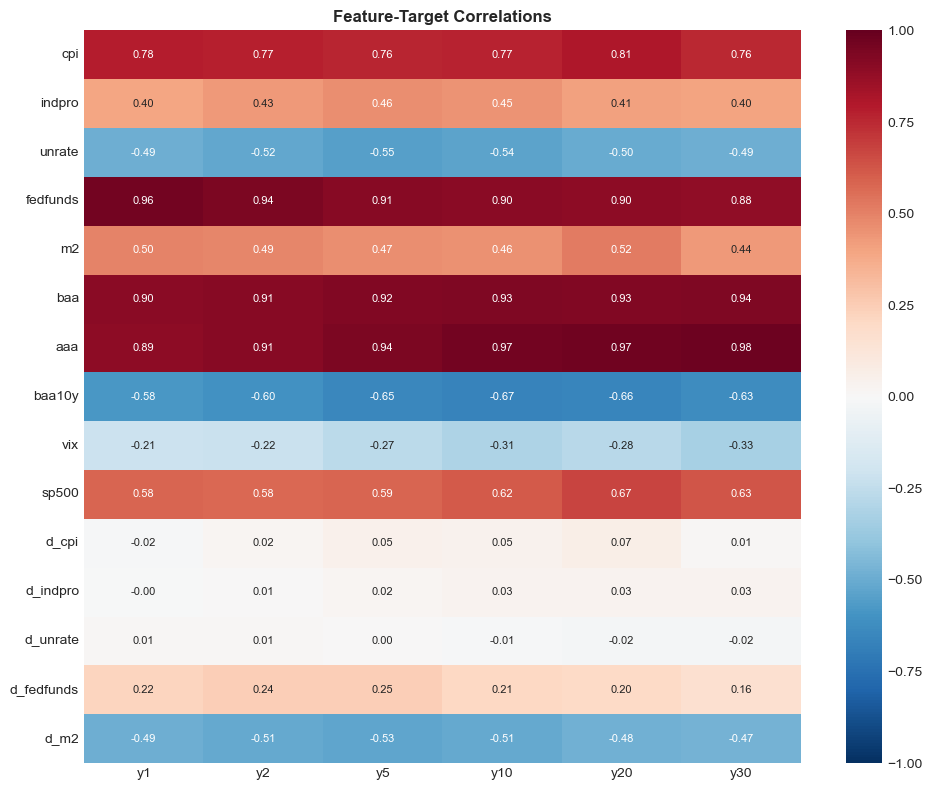

In [10]:
# Merge features and targets for correlation
combined = pd.concat([features[feature_cols], targets[TARGETS]], axis=1)

# Feature-target correlation matrix
corr_ft = combined.corr().loc[feature_cols, TARGETS]

plt.figure(figsize=(10, 8))
sns.heatmap(corr_ft, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            annot_kws={'size': 8}, vmin=-1, vmax=1)
plt.title('Feature-Target Correlations', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.2 Directional Intuition

In [11]:
# Expected economic relationships
expected_signs = {
    'fedfunds': '+',  # Higher fed funds → higher yields
    'cpi': '+',       # Higher inflation → higher yields
    'unrate': '-',    # Higher unemployment → lower yields (flight to safety)
    'vix': '-',       # Higher volatility → lower yields (flight to safety)
    'baa10y': '+',    # Credit spreads should correlate with risk premia
}

print("Directional Intuition Check (vs y10):")
print("=" * 50)
for var, expected in expected_signs.items():
    if var in corr_ft.index:
        actual = '+' if corr_ft.loc[var, 'y10'] > 0 else '-'
        match = '✓' if actual == expected else '✗'
        print(f"{var:12} | Expected: {expected} | Actual: {actual} | {match}")

Directional Intuition Check (vs y10):
fedfunds     | Expected: + | Actual: + | ✓
cpi          | Expected: + | Actual: + | ✓
unrate       | Expected: - | Actual: - | ✓
vix          | Expected: - | Actual: - | ✓
baa10y       | Expected: + | Actual: - | ✗


### 3.3 Target Correlation

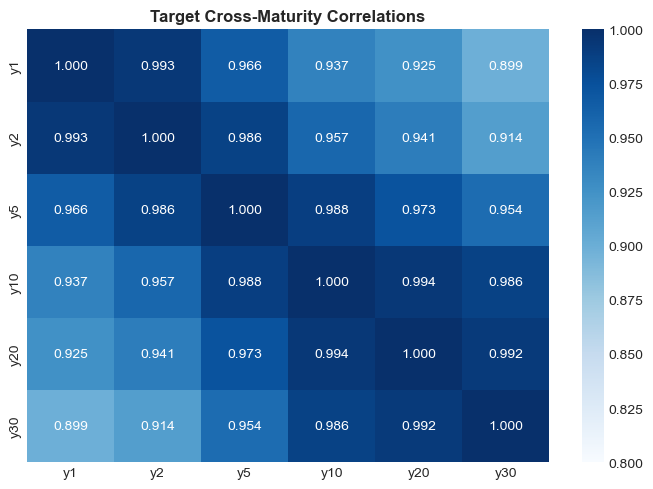


Key observation: Adjacent maturities are highly correlated (>0.95).
This justifies multi-output regression with attention across maturities.


In [12]:
# Cross-maturity correlations (should be high, declining with distance)
target_corr = targets[TARGETS].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(target_corr, annot=True, fmt='.3f', cmap='Blues', vmin=0.8, vmax=1)
plt.title('Target Cross-Maturity Correlations', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nKey observation: Adjacent maturities are highly correlated (>0.95).")
print("This justifies multi-output regression with attention across maturities.")